In [1]:
import pandas as pd
import datetime as dt

df = pd.read_csv('C:/ecommerce-churn-analysis/data/processed/clean_data.csv')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

max_date = df['InvoiceDate'].max()
print(f"Самая последняя покупака в датасете: {max_date}")

snapshot_date = max_date + dt.timedelta(days=1)
print(f"Дата отсчета для расчета Recency (Snapshot Date): {snapshot_date}")

df.head(3) 


Самая последняя покупака в датасете: 2011-12-09 12:50:00
Дата отсчета для расчета Recency (Snapshot Date): 2011-12-10 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSum
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00


In [2]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,

    'InvoiceNo': 'nunique',

    'TotalSum': 'sum'
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)

print(f"Всего уникальных клиентов в RFM-табилце: {len(rfm)}")
rfm.head()

Всего уникальных клиентов в RFM-табилце: 4338


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [3]:
print("--- ОПИСАТЕЛЬНАЯ СТАТИСТИКА ---")
display(rfm[['Recency', 'Frequency', 'Monetary']].describe())

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

rfm.head(10)



--- ОПИСАТЕЛЬНАЯ СТАТИСТИКА ---


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346,326,1,77183.60,1,1,4,114,6
1,12347,2,7,4310.00,4,4,4,444,12
2,12348,75,4,1797.24,2,3,4,234,9
3,12349,19,1,1757.55,3,1,4,314,8
4,12350,310,1,334.40,1,1,2,112,4
5,12352,36,8,2506.04,3,4,4,344,11
6,12353,204,1,89.00,1,1,1,111,3
7,12354,232,1,1079.40,1,1,3,113,5
8,12355,214,1,459.40,1,1,2,112,4
9,12356,23,3,2811.43,3,3,4,334,10


In [4]:
def segment_me(df):
    if df['R_Score'] == 4 and df['F_Score'] == 4: 
        return 'Sigmas' 
    elif df['R_Score'] >= 3 and df['F_Score'] >= 3:
        return 'Loyal Customers' 
    elif df['R_Score'] >= 3 and df['F_Score'] <= 2:
        return 'Promising / New'
    elif df['R_Score'] == 2 and df['F_Score'] >= 3:
        return 'At Risk' 
    elif df['R_Score'] <= 2 and df['F_Score'] <= 2:
        return 'Lost / Hibernating'
    else:
        return 'Need Attention'


rfm['Customer_Segment'] = rfm.apply(segment_me, axis=1)

segment_counts = rfm['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']
segment_counts['Share_%'] = (segment_counts['Count'] / len(rfm) * 100).round(2)

print("--- РАСПРЕДЕЛЕНИЕ КЛИЕНТОВ ПО СЕГМЕНТАМ ---")
display(segment_counts) 

--- РАСПРЕДЕЛЕНИЕ КЛИЕНТОВ ПО СЕГМЕНТАМ ---


,Segment,Count,Share_%
0,Lost / Hibernating,1504,34.67
1,Loyal Customers,914,21.07
2,Promising / New,665,15.33
3,Sigmas,609,14.04
4,At Risk,465,10.72
5,Need Attention,181,4.17


In [5]:
segment_analysis = rfm.groupby('Customer_Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['sum', 'mean']
}).reset_index()

segment_analysis.columns = [
    'Segment',
    'Customer_Count',
    'Avg_Recency_Days',
    'Avg_Frequency',
    'Total_Revenue',
    'Avg_Revenue_Per_Customer'
]


total_shop_revenue = segment_analysis['Total_Revenue'].sum() 
segment_analysis['Revenue_Share_%'] = (segment_analysis['Total_Revenue'] / total_shop_revenue * 100).round(2)

segment_analysis['Avg_Recency_Days'] = segment_analysis['Avg_Recency_Days'].round(1)
segment_analysis['Avg_Frequency'] = segment_analysis['Avg_Frequency'].round(1)
segment_analysis['Avg_Revenue_Per_Customer'] = segment_analysis['Avg_Revenue_Per_Customer'].round(2)
segment_analysis['Total_Revenue'] = segment_analysis['Total_Revenue'].round(2)

segment_analysis = segment_analysis.sort_values(by='Total_Revenue', ascending=False).reset_index(drop=True)

print(f"Общая выручка интернет-магазина: £{total_shop_revenue:,.2f}")
display(segment_analysis)





Общая выручка интернет-магазина: £8,887,208.89


,Segment,Customer_Count,Avg_Recency_Days,Avg_Frequency,Total_Revenue,Avg_Revenue_Per_Customer,Revenue_Share_%
0,Sigmas,609,7.6,13.7,4568618.83,7501.84,51.41
1,Loyal Customers,914,24.5,5.1,2015511.27,2205.15,22.68
2,At Risk,465,84.8,4.4,767776.84,1651.13,8.64
3,Lost / Hibernating,1504,186.6,1.3,765260.06,508.82,8.61
4,Promising / New,665,25.3,1.4,499604.37,751.28,5.62
5,Need Attention,181,207.6,3.7,270437.52,1494.13,3.04


C:\Users\User\AppData\Local\Temp\ipykernel_14596\47920282.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_14596\47920282.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


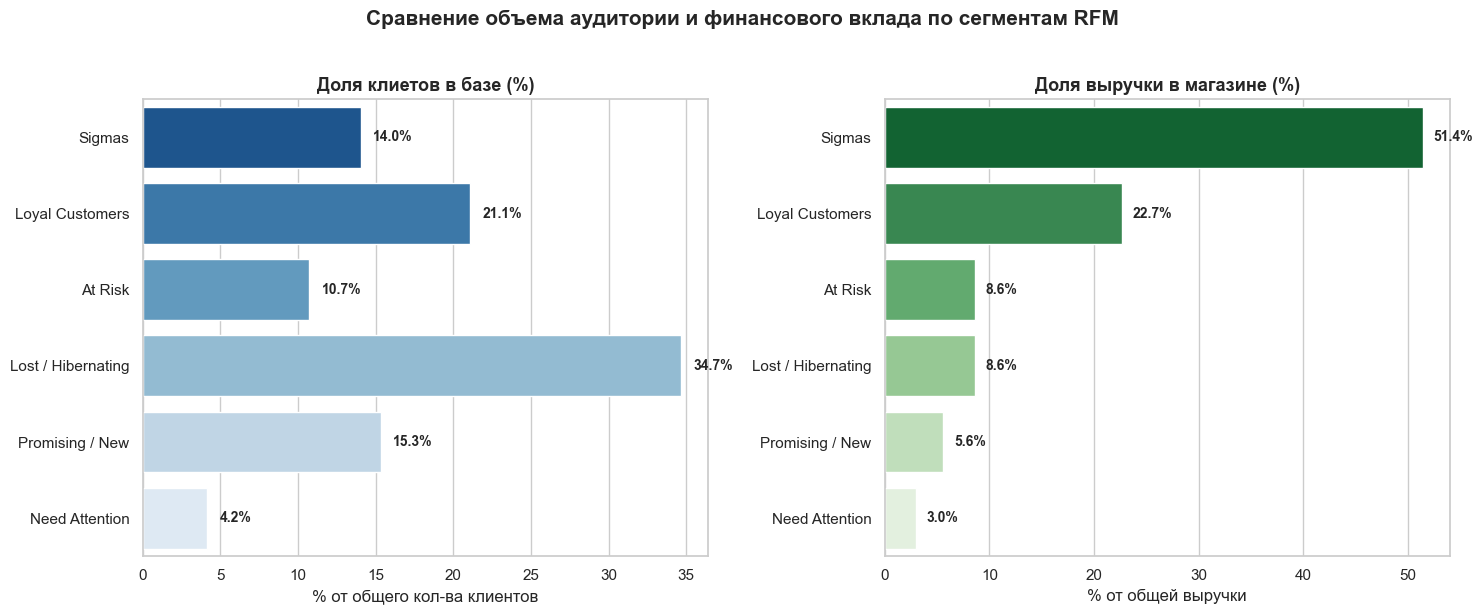

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

segment_analysis['Customer_Share_%'] = (segment_analysis['Customer_Count'] / len(rfm) * 100).round(2)

ax1 = sns.barplot(
    data=segment_analysis,
    x='Customer_Share_%',
    y='Segment',
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Доля клиетов в базе (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('% от общего кол-ва клиентов')
axes[0].set_ylabel('')

for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f'{width:.1f}%',
                 (width + 0.8, p.get_y() + p.get_height() / 2.),
                 va='center', fontsize=10, fontweight='bold')

ax2 = sns.barplot(
    data=segment_analysis,
    x='Revenue_Share_%',
    y='Segment',
    ax=axes[1],
    palette='Greens_r'
)

axes[1].set_title('Доля выручки в магазине (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('% от общей выручки')
axes[1].set_ylabel('')

for p in ax2.patches: 
    width = p.get_width()
    ax2.annotate(f'{width:.1f}%',
                 (width + 1.0, p.get_y() + p.get_height() / 2.),
                 va='center', fontsize=10, fontweight='bold')

plt.suptitle('Сравнение объема аудитории и финансового вклада по сегментам RFM', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Стратегия работы с RFM-сегментами (CRM & Marketing Plan)

### 1. Sigmas (14% клиентов | 51.4% выручки)
* **Цель:** Удержание и максимальная лояльность 
* **Дейтсвия:** 
    * Персональный VIP-сервис и выделенный менеджер. 
    * Закрытые предпродажи экслюзивных новинок.
    * Никаких спам-скидок (они и так покупают по полной цене); фокус на сервисе и ценности 

### 2. Loyal Customers (21.1% клиетов | 22.7 выручки)
* **Цель:** Перевод в категорию Sigmas (увеличение среднего чека).
* **Действия:** 
    * Программы накопления баллов/кэшбека.
    * Рекомендательные блоки (Cross-sell / Up-sell) на основе предыдущих покупок. 

### 3. At Risk (10.7% клиентов | 8.6% выручки) — ГЛАВНЫЙ ФОКУС ОТТОКА!
* **Цель:** Срочная реанимация до перехода в категорию Lost.
* **Действия:**
    * Автоматическая триггерная цепочка (Email / SMS / Push): По типу ("Мы скучаем!") (e.g duolingo).
    * Персональный промокод с ограниченным сроком  действия (например, 7 дней).
    * Опрос об опыте взаимодействия (поечму перестали покупать?).

### 4. Promising / New (15.3% клиентов | 5.6% выручки)
* **Цель:** Вторая покупка (Retention в первые 30 дней).
* **Действия:**
    * Приветственная серия писем (Welcome-серия): инструкция по использованию сервиса, подборка хитов продаж.
    * Скидка на *второй* заказ в течение 14 дней после первого.

### 5. Lost / Hibernating (34.7% клиентов | 8.6% выручки)
* **Цель:** Дешевый реактивационный маркетинг (без лишних затрат).
* **Действия:**
  * Автоматическая e-mail рассылка 1 раз в квартал во время крупных распродаж (Черная Пятница, Новый Год).
  * Исключить из платных каналов таргетированной рекламы, чтобы не выжигать бюджет.


In [7]:
output_path = 'C:/ecommerce-churn-analysis/data/processed/rfm_segmented.csv'
rfm.to_csv(output_path, index=False) 

print(f" Файл успешно сохранен: {output_path}")


 Файл успешно сохранен: C:/ecommerce-churn-analysis/data/processed/rfm_segmented.csv
